In [1]:
import numpy as np
import random
import numba
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import pandas as pd
import os


In [2]:
# Base Parameters
J = 1 
beta_steps = 75
beta = np.linspace(0.1, 0.8, beta_steps) 
Nthermalization_MRT2 = int(10e5) 
Nthermalization_Wolff = int(10e4)
Nsample = 2**14 


Tc_ground = 2 / np.log(1 + np.sqrt(2))

L_values = [4, 8, 16]

In [3]:
class Index:
    '''utility class to make to wolff marginally more legible. holds an index pair. (Usage optional) '''
    def __init__(self, i, j):
        self.i = i
        self.j = j

@numba.njit
def _wolff_step_numba(spins, wolff_marker, L, wolff_prob):
    wolff_marker.fill(0)
    
    i0 = np.random.randint(0, L)
    j0 = np.random.randint(0, L)
    ground_spin = spins[i0, j0]
    wolff_marker[i0, j0] = 1
    
    # use a simple array-based stack instead of list of tuples
    stack = np.zeros((L*L, 2), dtype=np.int64)
    stack[0, 0] = i0
    stack[0, 1] = j0
    stack_size = 1
    
    dirs = [(-1,0),(1,0),(0,-1),(0,1)]
    while stack_size > 0:
        stack_size -= 1
        ci = stack[stack_size, 0]
        cj = stack[stack_size, 1]
        for d in range(4):
            ni = (ci + dirs[d][0]) % L
            nj = (cj + dirs[d][1]) % L
            if wolff_marker[ni, nj] == 0 and spins[ni, nj] == ground_spin:
                if np.random.random() < wolff_prob:
                    wolff_marker[ni, nj] = 1
                    stack[stack_size, 0] = ni
                    stack[stack_size, 1] = nj
                    stack_size += 1
    
    N_cluster = np.sum(wolff_marker == 1)
    spins[wolff_marker == 1] *= -1
    return spins, N_cluster, ground_spin

@numba.njit
def _wolff_step_numba(spins, wolff_marker, L, wolff_prob):
    wolff_marker.fill(0)
    
    i0 = np.random.randint(0, L)
    j0 = np.random.randint(0, L)
    ground_spin = spins[i0, j0]
    wolff_marker[i0, j0] = 1
    
    stack = np.zeros((L*L, 2), dtype=np.int64)
    stack[0, 0] = i0
    stack[0, 1] = j0
    stack_size = 1
    
    while stack_size > 0:
        stack_size -= 1
        ci = stack[stack_size, 0]
        cj = stack[stack_size, 1]
        for d in range(4):
            ni = (ci + (d==1) - (d==0)) % L
            nj = (cj + (d==3) - (d==2)) % L
            if wolff_marker[ni, nj] == 0 and spins[ni, nj] == ground_spin:
                if np.random.random() < wolff_prob:
                    wolff_marker[ni, nj] = 1
                    stack[stack_size, 0] = ni
                    stack[stack_size, 1] = nj
                    stack_size += 1
    
    # replace boolean indexing with explicit loop
    N_cluster = 0
    for i in range(L):
        for j in range(L):
            if wolff_marker[i, j] == 1:
                spins[i, j] *= -1
                N_cluster += 1
    
    return spins, N_cluster, ground_spin

class IsingMC_Wolff:
    def __init__(self, length, temperature=0.):
        self.spins = np.random.choice([-1, 1], size=(length, length)).astype(int)
        self.L = length
        self.T = temperature
        self.M = int(np.sum(self.spins))
        self.wolff_prob = None
        self.wolff_marker = np.zeros((length,length),dtype=int) #container to mark which sites are in the cluster
        self.update_probabilities()
    
    def update_probabilities(self):
        '''we calculate the probability in the beginning so we don't have to recompute it'''
        if(self.T != 0.):
            self.wolff_prob = 1. - np.exp(-2./self.T)
           
        else:
            self.wolff_prob = 1. #at zero temperature we always add to the cluster
          
    def set_temperature(self, temperature):
        '''set temperature and update the probability'''
        self.T = temperature
        self.update_probabilities()
    
    def reset_spins(self):
        '''this resets the spins to the all-up state '''
        self.spins.fill(1)
        self.M = self.L * self.L

    def magnetisation(self):
        return np.abs(self.M) / (self.L ** 2)

    def update_magnetisation(self, ground_spin):
        """call this after building cluster but before flipping"""
        N_cluster = np.sum(self.wolff_marker == 1)
        self.M -= 2 * ground_spin * N_cluster

    def wolff_step(self):
        self.spins, N_cluster, ground_spin = _wolff_step_numba(
            self.spins, self.wolff_marker, self.L, self.wolff_prob)
        self.M -= 2 * ground_spin * N_cluster

    def run_binning_analysis_wolff(self, Nsamples, Ninit, max_l):
        """ implements the binning method for computing the autocorrelation time. """

        # Nsamples = total number of samples to obtain (after discarding thermalising)
        # Ninit = numer of initial samples to discard in the beggining of the simulation
        # max_l = maximum level of binning, with 2**max_l samples in each bin
        
        assert np.log2(Nsamples).is_integer() # works only for  Nsamples =  power of two

        self.spins = np.random.choice([-1, 1], size=(self.L, self.L))
        self.M = int(np.sum(self.spins))  # sync M with the newly drawn spins

        #thermalisation
        for _ in range(Ninit):
            self.wolff_step()

        #sample
        M_data = np.zeros(Nsamples)

        start = time.perf_counter()
        for step in range(Nsamples):
            self.wolff_step()
            M_data[step] = self.magnetisation()
        time_Wolff = time.perf_counter() - start


        M0 = Nsamples
        M_mean = np.mean(M_data) # note that the mean is unaffected by binning)
        
        Delta_ls = []
        Als = np.copy(M_data)
        for l in range(max_l):
            Ml = M0/(2**l)
            Delta_l = np.sqrt(1/(Ml*(Ml-1)) * np.sum((Als-M_mean)**2))
            Delta_ls.append(Delta_l)

            Als = np.copy((Als[::2] + Als[1::2])/2)
            
        return np.array(Delta_ls), time_Wolff

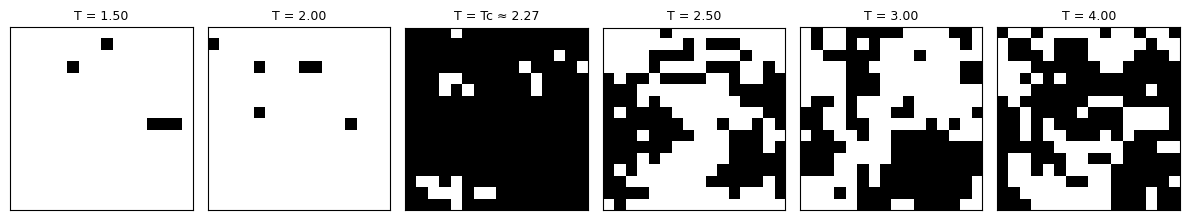

In [ ]:
## example use


# Spin configuration plots for L=16 at different temperatures
L = 16
Tc = 2 / np.log(1 + np.sqrt(2))  # ≈ 2.269

temperatures = [1.5, 2.0, Tc, 2.5, 3.0, 4.0]
Ntherm = 5000   # Wolff steps to thermalize
model = IsingMC_Wolff(L)

fig, axes = plt.subplots(1, len(temperatures), figsize=(len(temperatures) * 2, 2.2))

for ax, T in zip(axes, temperatures):
    model.spins = np.random.choice([-1, 1], size=(L, L)).astype(int)
    model.set_temperature(T)
    for _ in range(Ntherm):
        model.wolff_step()

    ax.imshow(model.spins, cmap='binary', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    label = f"T = {T:.2f}" if T != Tc else f"T = Tc ≈ {Tc:.2f}"
    ax.set_title(label, fontsize=9)

plt.tight_layout()
plt.savefig("spin_configs_L16.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
output_dir = "spin_configs"
os.makedirs(output_dir, exist_ok=True)

L_values_data = [10, 20, 30, 40, 50, 60]
temperatures_data = np.linspace(1, 4, 60)
Ntherm = 5000

for L in L_values_data:
    model = IsingMC_Wolff(L)
    for T in tqdm(temperatures_data, desc=f"L={L}"):
        model.spins = np.random.choice([-1, 1], size=(L, L)).astype(int)
        model.M = int(np.sum(model.spins))
        model.set_temperature(T)
        for _ in range(Ntherm):
            model.wolff_step()

        fig, ax = plt.subplots(figsize=(2, 2))
        ax.imshow(model.spins, cmap='binary', vmin=-1, vmax=1, interpolation='nearest')
        ax.axis('off')
        plt.tight_layout(pad=0)
        T_int = int(round(T * 10000))
        fname = os.path.join(output_dir, f"spin_config_L{L}_T{T_int}.png")
        plt.savefig(fname, dpi=100, bbox_inches='tight', pad_inches=0)
        plt.close(fig)

print(f"Saved {len(L_values_data) * len(temperatures_data):.0f} images to '{output_dir}/'")


L=60: 100%|██████████| 60/60 [00:15<00:00,  3.95it/s]

Saved 360 images to 'spin_configs/'
